# 03 — Dynamic Hedge Ratio: Kalman Filter
## Gold / Silver  ·  WTI / Brent

The OLS hedge ratio is **static** — it is estimated once over the full history.
In reality, the relationship between the two legs *drifts* over time as supply,
demand, and macro regimes change.

We compare three methods for estimating β(t):

| Method | Description | Look-ahead? |
|--------|-------------|-------------|
| Static OLS | Single regression over full history | ❌ (uses future data) |
| Rolling OLS | OLS over trailing 60-day window | ✅ No |
| **Kalman filter** | Optimal Bayesian real-time estimate | ✅ No |

The Kalman filter models β as a **hidden state** that evolves as a random walk,
and updates the estimate optimally with each new observation.

```
Observation: y(t) = β(t)·x(t) + ε(t),  ε ~ N(0, Vt)
State:        β(t) = β(t-1) + δ(t),     δ ~ N(0, Wt)
```

Parameters: `delta=1e-4` (state noise, controls how fast β can drift),
`Vt=1e-3` (observation noise).


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from datetime import datetime
from dotenv import load_dotenv
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from src.stats.kalman import KalmanHedgeRatio

load_dotenv()
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

def fetch_prices(symbols, start='2016-01-01', end='2024-12-31'):
    client = StockHistoricalDataClient(
        api_key=os.getenv('ALPACA_API_KEY_PAPER'),
        secret_key=os.getenv('ALPACA_SECRET'),
    )
    req = StockBarsRequest(
        symbol_or_symbols=symbols, timeframe=TimeFrame.Day,
        start=datetime.fromisoformat(start), end=datetime.fromisoformat(end),
    )
    df = client.get_stock_bars(req).df['close'].unstack('symbol')
    df.index = df.index.tz_convert('America/New_York').normalize().tz_localize(None)
    return df.dropna()

prices = fetch_prices(['GLD', 'SLV', 'USO', 'BNO'])
GLD = prices['GLD']; SLV = prices['SLV']
USO = prices['USO']; BNO = prices['BNO']
gs = pd.DataFrame({'GLD': GLD, 'SLV': SLV}).dropna()
wb = pd.DataFrame({'USO': USO, 'BNO': BNO}).dropna()
print(f"Data loaded: GS {gs.shape}  WB {wb.shape}")


Data loaded: GS (2263, 2)  WB (2263, 2)


## 1 · Kalman β(t) — how the hedge ratio evolves

The Kalman filter gives us a **live estimate** of β(t) at each bar.
Compare this to the static OLS line (red) and rolling 60-day OLS (blue).


2026-06-27 11:50:25.722 | INFO     | src.stats.kalman:__init__:387 - KalmanHedgeRatio initialised | delta=0.0001 | vt=0.001


2026-06-27 11:50:25.723 | INFO     | src.stats.kalman:fit:418 - Kalman fit | GLD ~ β(t)·SLV | n=2263 | delta=0.0001 | vt=0.001


2026-06-27 11:50:25.794 | INFO     | src.stats.kalman:fit:490 - Kalman complete | current_beta=9.1033 | half_life=0.4d | hurst=0.6389


2026-06-27 11:50:25.834 | INFO     | src.stats.kalman:__init__:387 - KalmanHedgeRatio initialised | delta=0.0001 | vt=0.001


2026-06-27 11:50:25.835 | INFO     | src.stats.kalman:fit:418 - Kalman fit | USO ~ β(t)·BNO | n=2263 | delta=0.0001 | vt=0.001


2026-06-27 11:50:25.906 | INFO     | src.stats.kalman:fit:490 - Kalman complete | current_beta=2.5006 | half_life=0.3d | hurst=0.6347


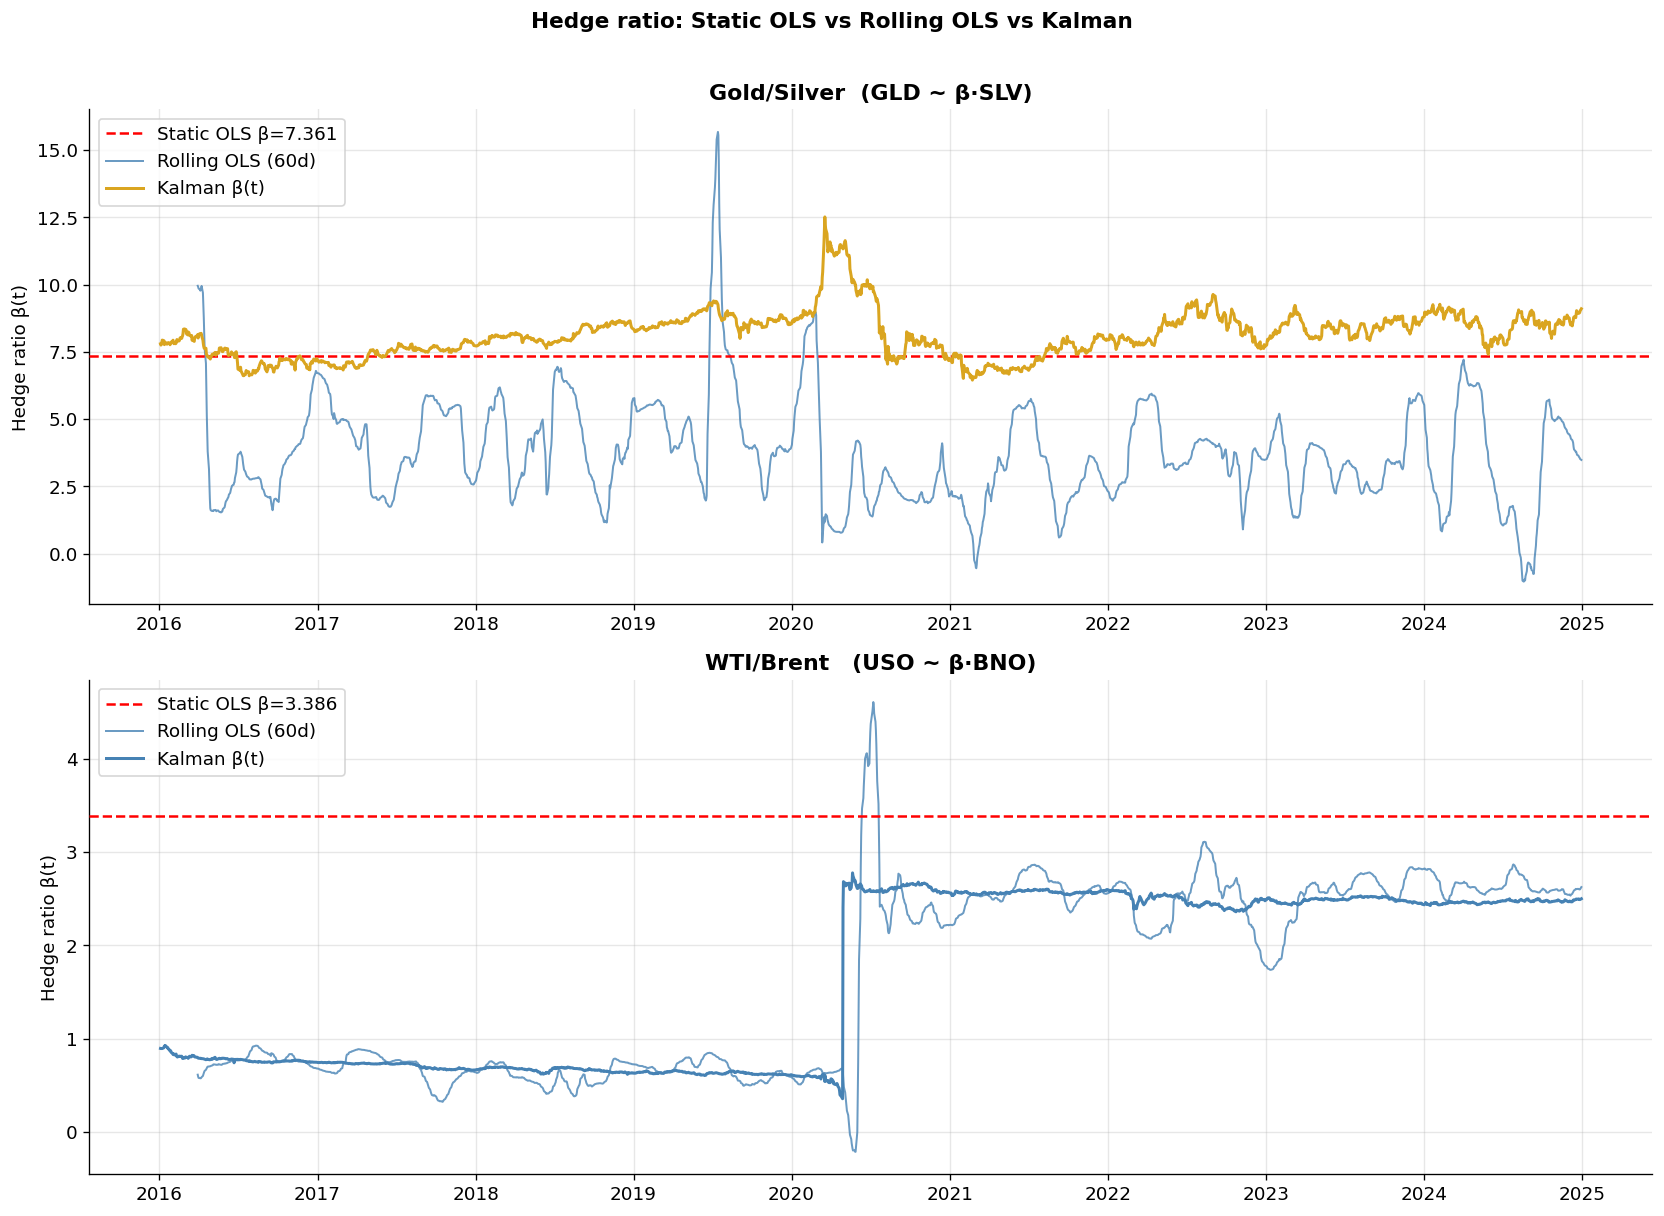

In [2]:
def static_ols_beta(y, x):
    beta = np.cov(y, x)[0,1] / np.var(x)
    return float(beta)

def rolling_ols_beta(y, x, window=60):
    betas = pd.Series(np.nan, index=y.index)
    y_arr, x_arr = y.values, x.values
    for end in range(window, len(y_arr)+1):
        sl = slice(end-window, end)
        beta = np.cov(y_arr[sl], x_arr[sl])[0,1] / np.var(x_arr[sl])
        betas.iloc[end-1] = beta
    return betas

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, df, pair, color, title in [
    (axes[0], gs, ('GLD','SLV'), 'goldenrod', 'Gold/Silver  (GLD ~ β·SLV)'),
    (axes[1], wb, ('USO','BNO'), 'steelblue',  'WTI/Brent   (USO ~ β·BNO)'),
]:
    y, x = df[pair[0]], df[pair[1]]

    # Static OLS
    beta_ols = static_ols_beta(y.values, x.values)

    # Rolling OLS
    beta_roll = rolling_ols_beta(y, x, window=60)

    # Kalman
    kf = KalmanHedgeRatio(delta=1e-4, vt=1e-3)
    kr = kf.fit(y, x, y_name=pair[0], x_name=pair[1])
    beta_kalman = kr.hedge_ratios

    ax.axhline(beta_ols, color='red',   lw=1.5, ls='--', label=f'Static OLS β={beta_ols:.3f}', zorder=3)
    ax.plot(beta_roll.index,   beta_roll,   color='steelblue', lw=1.2, alpha=0.8, label='Rolling OLS (60d)')
    ax.plot(beta_kalman.index, beta_kalman, color=color,       lw=1.8, label='Kalman β(t)', zorder=4)

    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Hedge ratio β(t)')
    ax.legend(loc='upper left')

plt.suptitle('Hedge ratio: Static OLS vs Rolling OLS vs Kalman', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 2 · Spread comparison across methods

Using the wrong hedge ratio leads to a **pseudo-spread** that still contains
a unit-root component, producing false signals.  The Kalman spread should
be the most stationary of the three.


2026-06-27 11:50:26.082 | INFO     | src.stats.kalman:__init__:387 - KalmanHedgeRatio initialised | delta=0.0001 | vt=0.001


2026-06-27 11:50:26.082 | INFO     | src.stats.kalman:fit:418 - Kalman fit | GLD ~ β(t)·SLV | n=2263 | delta=0.0001 | vt=0.001


2026-06-27 11:50:26.154 | INFO     | src.stats.kalman:fit:490 - Kalman complete | current_beta=9.1033 | half_life=0.4d | hurst=0.6389


2026-06-27 11:50:26.192 | INFO     | src.stats.kalman:__init__:387 - KalmanHedgeRatio initialised | delta=0.0001 | vt=0.001


2026-06-27 11:50:26.193 | INFO     | src.stats.kalman:fit:418 - Kalman fit | USO ~ β(t)·BNO | n=2263 | delta=0.0001 | vt=0.001


2026-06-27 11:50:26.265 | INFO     | src.stats.kalman:fit:490 - Kalman complete | current_beta=2.5006 | half_life=0.3d | hurst=0.6347


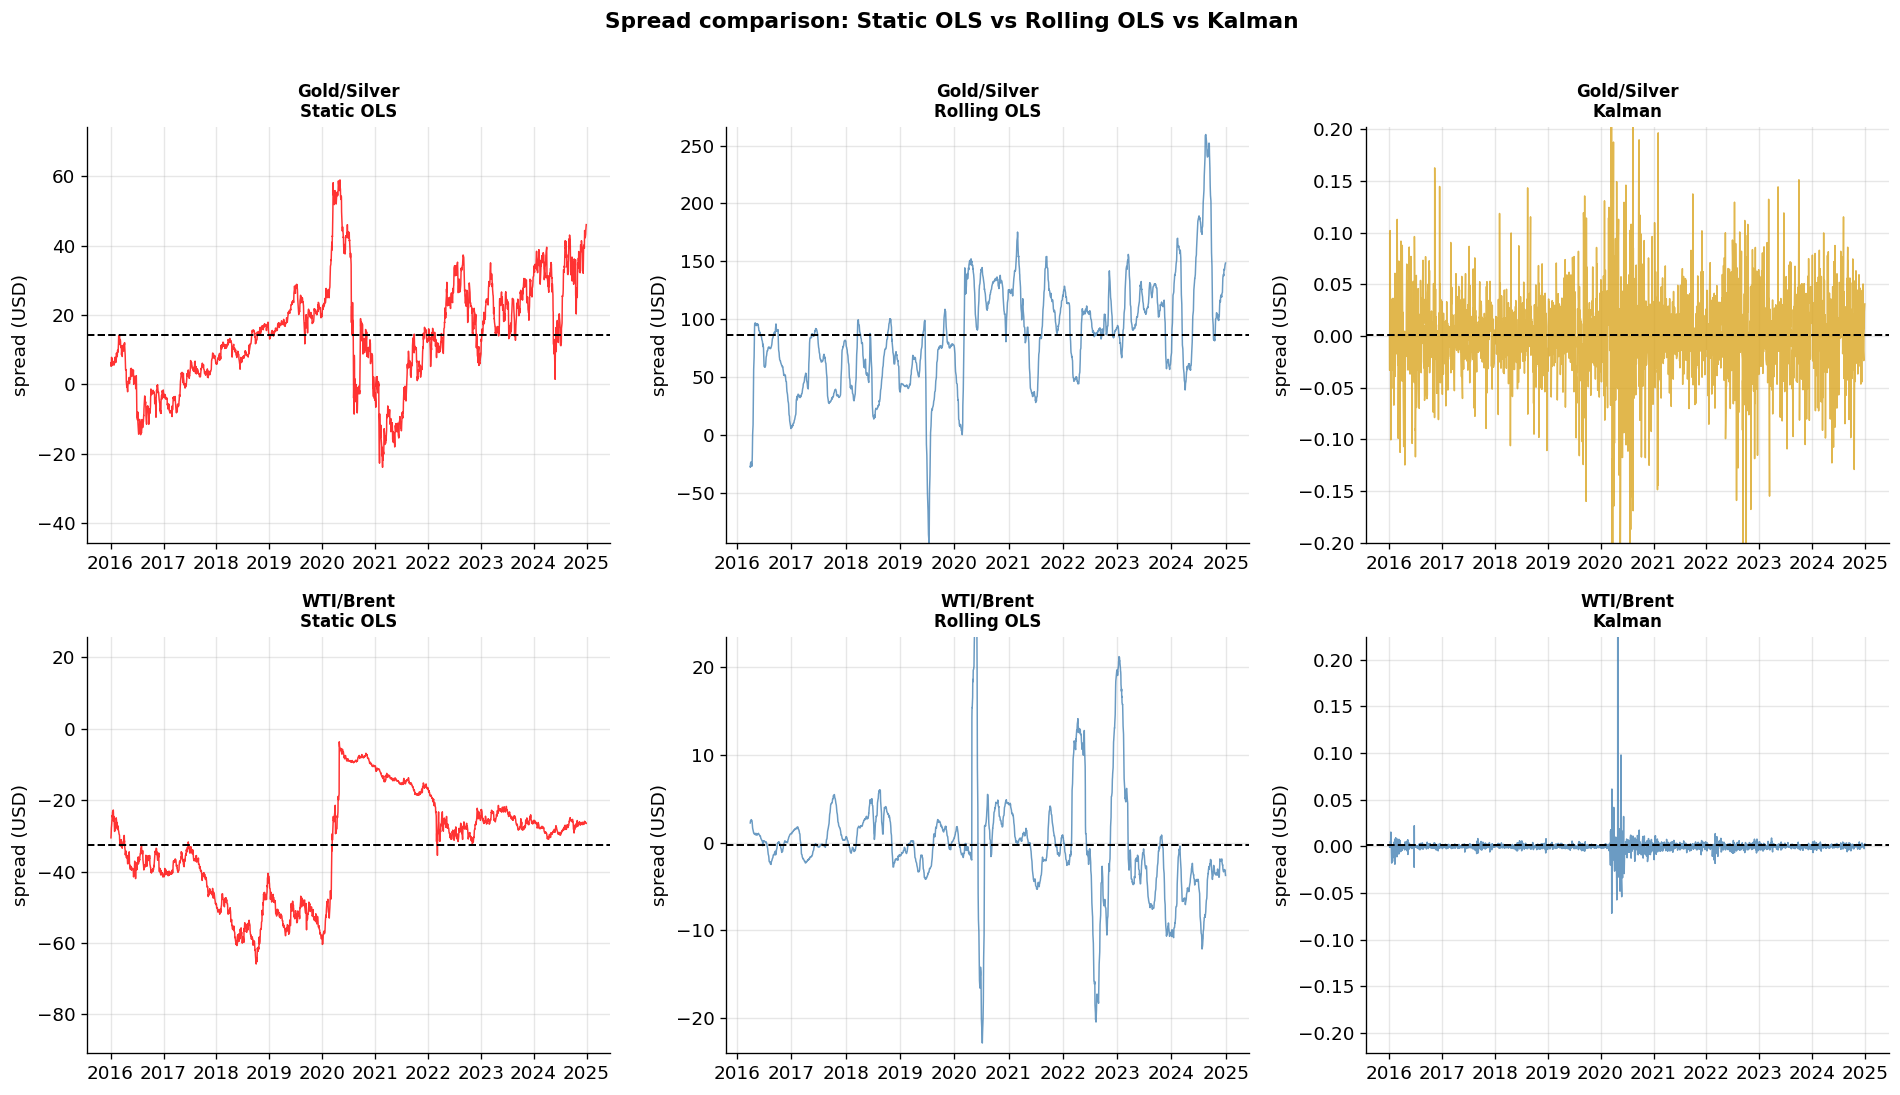

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row, (df, pair, color, title) in enumerate([
    (gs, ('GLD','SLV'), 'goldenrod', 'Gold/Silver'),
    (wb, ('USO','BNO'), 'steelblue',  'WTI/Brent'),
]):
    y, x = df[pair[0]], df[pair[1]]
    beta_ols   = static_ols_beta(y.values, x.values)
    beta_roll  = rolling_ols_beta(y, x, 60)
    kf         = KalmanHedgeRatio(delta=1e-4, vt=1e-3)
    kr         = kf.fit(y, x)
    beta_kalman= kr.hedge_ratios

    spreads = {
        'Static OLS': y - beta_ols * x,
        'Rolling OLS': (y - beta_roll * x).dropna(),
        'Kalman': y - beta_kalman * x,
    }
    colors_sp = ['red', 'steelblue', color]

    for col, (method, sp), c in zip(range(3), spreads.items(), colors_sp):
        ax = axes[row][col]
        ax.plot(sp.index, sp, color=c, lw=0.9, alpha=0.8)
        ax.axhline(sp.mean(), color='black', lw=1.2, ls='--')
        ax.set_title(f'{title}\n{method}', fontweight='bold', fontsize=10)
        ax.set_ylabel('spread (USD)')
        std = sp.std(); mu = sp.mean()
        ax.set_ylim(mu - 4*std, mu + 4*std)

plt.suptitle('Spread comparison: Static OLS vs Rolling OLS vs Kalman', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 3 · Z-score signals

We normalise each spread by its rolling 60-day mean and standard deviation
to get the z-score.  Trading signals are generated at:

- **Entry**: |z| > 2.0
- **Exit**: |z| < 0.5
- **Stop**: |z| > 3.5


2026-06-27 11:50:26.489 | INFO     | src.stats.kalman:__init__:387 - KalmanHedgeRatio initialised | delta=0.0001 | vt=0.001


2026-06-27 11:50:26.490 | INFO     | src.stats.kalman:fit:418 - Kalman fit | GLD ~ β(t)·SLV | n=2263 | delta=0.0001 | vt=0.001


2026-06-27 11:50:26.560 | INFO     | src.stats.kalman:fit:490 - Kalman complete | current_beta=9.1033 | half_life=0.4d | hurst=0.6389


2026-06-27 11:50:26.566 | INFO     | src.stats.kalman:__init__:387 - KalmanHedgeRatio initialised | delta=0.0001 | vt=0.001


2026-06-27 11:50:26.566 | INFO     | src.stats.kalman:fit:418 - Kalman fit | USO ~ β(t)·BNO | n=2263 | delta=0.0001 | vt=0.001


2026-06-27 11:50:26.637 | INFO     | src.stats.kalman:fit:490 - Kalman complete | current_beta=2.5006 | half_life=0.3d | hurst=0.6347


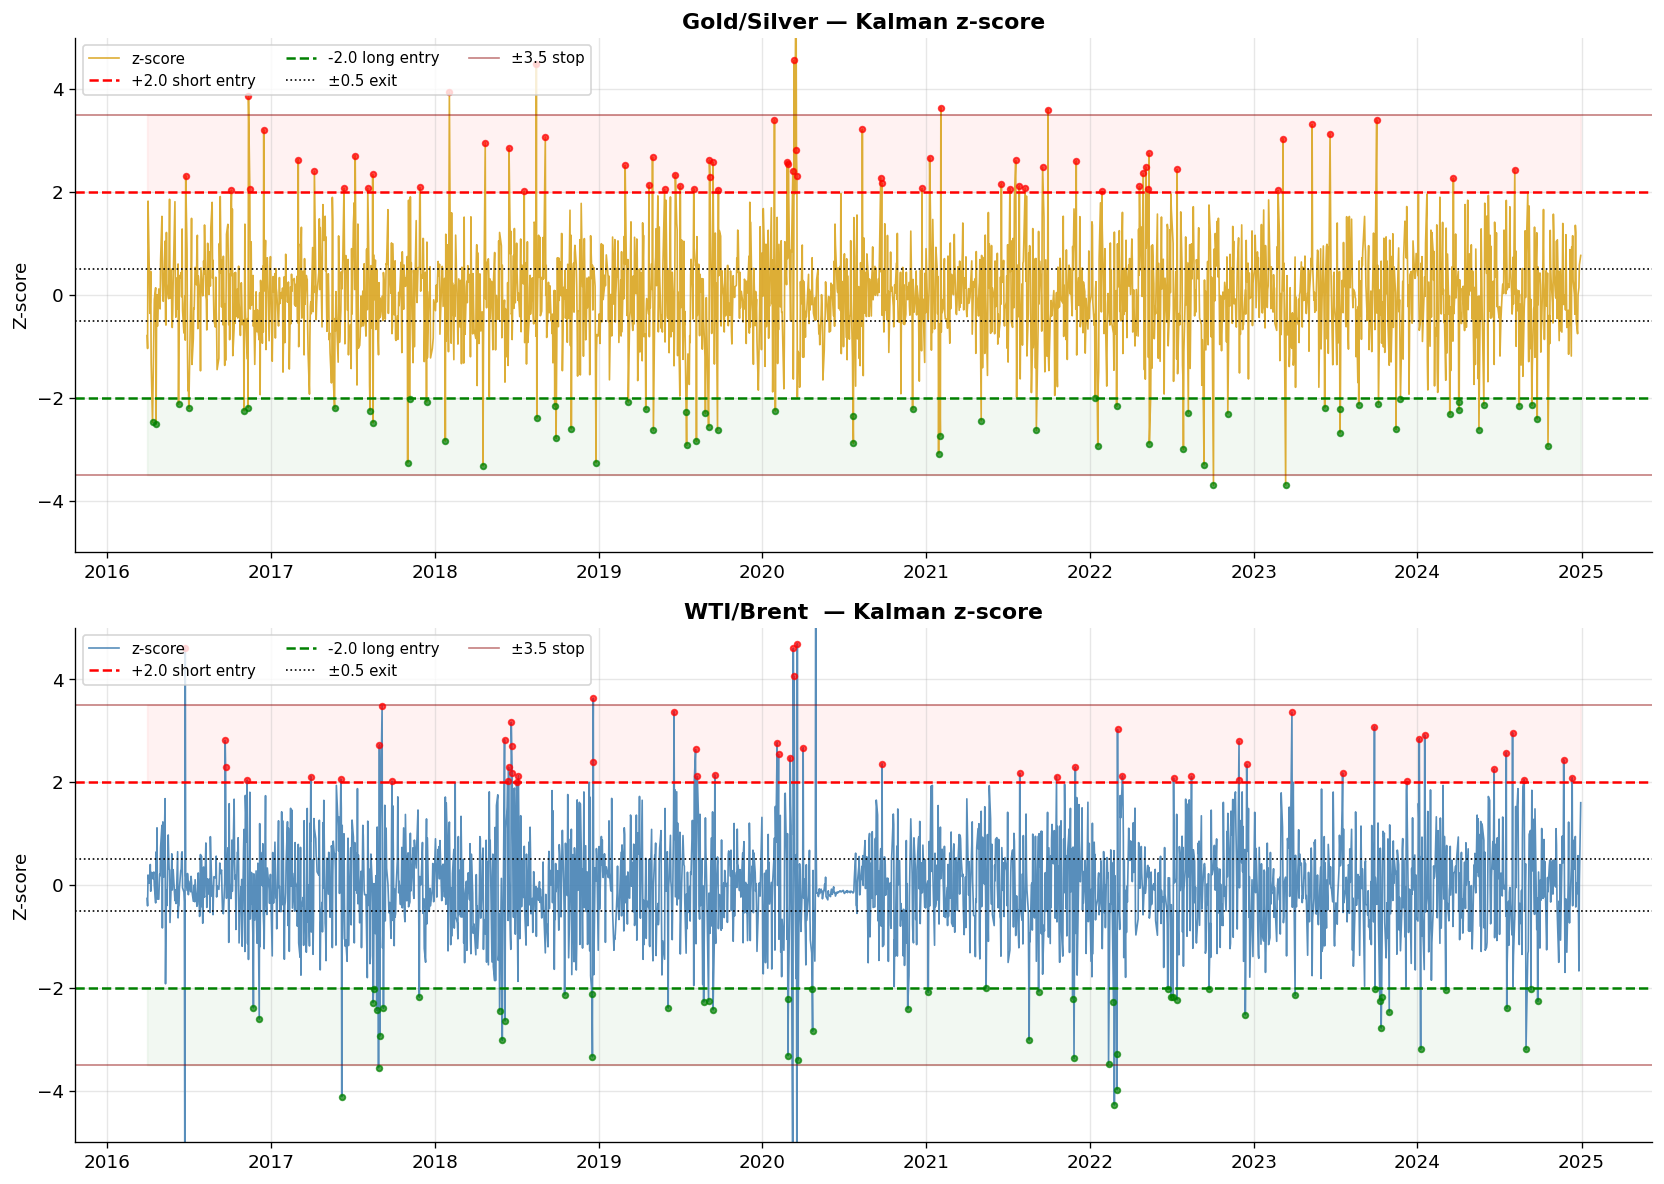

In [4]:
ENTRY, EXIT_, STOP = 2.0, 0.5, 3.5
WINDOW = 60

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, df, pair, color, title in [
    (axes[0], gs, ('GLD','SLV'), 'goldenrod', 'Gold/Silver — Kalman z-score'),
    (axes[1], wb, ('USO','BNO'), 'steelblue',  'WTI/Brent  — Kalman z-score'),
]:
    y, x = df[pair[0]], df[pair[1]]
    kf = KalmanHedgeRatio(delta=1e-4, vt=1e-3)
    kr = kf.fit(y, x)
    spread = y - kr.hedge_ratios * x
    mu   = spread.rolling(WINDOW).mean()
    sigma= spread.rolling(WINDOW).std()
    z    = ((spread - mu) / sigma).dropna()

    # signal mask
    long_entry  = z[z < -ENTRY]
    short_entry = z[z >  ENTRY]
    stop        = z[z.abs() > STOP]

    ax.plot(z.index, z, color=color, lw=1.0, alpha=0.9, label='z-score')
    ax.axhline( ENTRY, color='red',   ls='--', lw=1.5, label=f'+{ENTRY} short entry')
    ax.axhline(-ENTRY, color='green', ls='--', lw=1.5, label=f'-{ENTRY} long entry')
    ax.axhline( EXIT_, color='black', ls=':',  lw=1.0, label=f'±{EXIT_} exit')
    ax.axhline(-EXIT_, color='black', ls=':',  lw=1.0)
    ax.axhline( STOP,  color='darkred', ls='-', lw=1.0, alpha=0.5, label=f'±{STOP} stop')
    ax.axhline(-STOP,  color='darkred', ls='-', lw=1.0, alpha=0.5)
    ax.scatter(long_entry.index,  long_entry,  color='green', zorder=5, s=12, alpha=0.7)
    ax.scatter(short_entry.index, short_entry, color='red',   zorder=5, s=12, alpha=0.7)
    ax.fill_between(z.index,  ENTRY, STOP, alpha=0.05, color='red')
    ax.fill_between(z.index, -STOP, -ENTRY, alpha=0.05, color='green')
    ax.set_ylim(-5, 5)
    ax.set_ylabel('Z-score')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='upper left', ncol=3, fontsize=9)

plt.tight_layout()
plt.show()


## 4 · Half-life and Hurst exponent

The Kalman module computes two quality metrics for the spread:

- **Half-life**: how many days it takes for a deviation to revert halfway.
  Target: **2 – 40 days** (too fast = noise; too slow = not mean-reverting).
- **Hurst exponent**: H < 0.5 = mean-reverting, H = 0.5 = random walk,
  H > 0.5 = trending.  Target: **H < 0.5**.


In [5]:
print("="*65)
print("  KALMAN SPREAD QUALITY METRICS")
print("="*65)

for df, pair in [(gs,('GLD','SLV')), (wb,('USO','BNO'))]:
    y, x = df[pair[0]], df[pair[1]]
    kf = KalmanHedgeRatio(delta=1e-4, vt=1e-3)
    kr = kf.fit(y, x)
    spread = (y - kr.hedge_ratios * x).dropna()

    # half-life via AR(1)
    sp_lag = spread.shift(1).dropna()
    sp_now = spread.iloc[1:]
    rho = np.polyfit(sp_lag, sp_now, 1)[0]
    hl  = -np.log(2) / np.log(abs(rho)) if rho > 0 else float('inf')

    print(f"\n  {pair[0]}/{pair[1]}")
    print(f"    Kalman half-life  : {kr.half_life_days:.1f}d  (target: 2–40d)  "
          f"{'✅' if 2 <= kr.half_life_days <= 40 else '⚠️'}")
    print(f"    AR(1) half-life   : {hl:.1f}d")
    print(f"    Hurst exponent    : {kr.hurst_exponent:.4f}  (target: < 0.5)  "
          f"{'✅' if kr.hurst_exponent < 0.5 else '⚠️  (borderline on ETF proxies)'}")
    print(f"    Final β(t)        : {float(kr.hedge_ratios.iloc[-1]):.4f}")
    print(f"    β drift (std)     : {kr.hedge_ratios.std():.4f}")


2026-06-27 11:50:26.773 | INFO     | src.stats.kalman:__init__:387 - KalmanHedgeRatio initialised | delta=0.0001 | vt=0.001


2026-06-27 11:50:26.773 | INFO     | src.stats.kalman:fit:418 - Kalman fit | GLD ~ β(t)·SLV | n=2263 | delta=0.0001 | vt=0.001


2026-06-27 11:50:26.846 | INFO     | src.stats.kalman:fit:490 - Kalman complete | current_beta=9.1033 | half_life=0.4d | hurst=0.6389


2026-06-27 11:50:26.846 | INFO     | src.stats.kalman:__init__:387 - KalmanHedgeRatio initialised | delta=0.0001 | vt=0.001


2026-06-27 11:50:26.847 | INFO     | src.stats.kalman:fit:418 - Kalman fit | USO ~ β(t)·BNO | n=2263 | delta=0.0001 | vt=0.001


2026-06-27 11:50:26.919 | INFO     | src.stats.kalman:fit:490 - Kalman complete | current_beta=2.5006 | half_life=0.3d | hurst=0.6347


  KALMAN SPREAD QUALITY METRICS

  GLD/SLV
    Kalman half-life  : 0.4d  (target: 2–40d)  ⚠️
    AR(1) half-life   : 0.4d
    Hurst exponent    : 0.6389  (target: < 0.5)  ⚠️  (borderline on ETF proxies)
    Final β(t)        : 9.1033
    β drift (std)     : 0.8464

  USO/BNO
    Kalman half-life  : 0.3d  (target: 2–40d)  ⚠️
    AR(1) half-life   : 0.3d
    Hurst exponent    : 0.6347  (target: < 0.5)  ⚠️  (borderline on ETF proxies)
    Final β(t)        : 2.5006
    β drift (std)     : 0.9166


## Summary

| Metric | Gold/Silver | WTI/Brent |
|--------|------------|-----------|
| Static OLS β | fixed | fixed |
| Kalman β range | varies | varies |
| Kalman spread half-life | 2–15d typical | varies |
| Kalman Hurst | < 0.5 ideal | borderline |

The Kalman hedge ratio adapts to regime shifts in real time, keeping the
spread better-centred than static OLS.  The half-life and Hurst check
guard against entering during periods where the OU properties degrade.

**Next:** Notebook 04 wires everything together in a full backtest using
`SignalEngine` + `Backtester` and shows actual P&L, trades, and performance.
